## Spotify Preprocessing & Exploratory Data Analysis (EDA)

### 1. Setup & Data Loading

#### 1.1 Setup

In [174]:
import os 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

DATA_PATH = "../data/raw/spotify_tracks.csv"    # adjust if notebook path differs

#### 1.2 Data Loading

In [175]:
# Load the dataset
df = pd.read_csv(DATA_PATH)

# Display first few rows of the dataset
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


#### 1.3 Initial Data Inspection

In [176]:
shape = df.shape
print(f"Dataset shape: {shape}")

print()

# Display column names and data types
print(df.info())


Dataset shape: (114000, 21)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  floa

In [177]:
print("Basic Statistics:")

# Display basic statistics
print(df.describe())

Basic Statistics:
          Unnamed: 0     popularity   duration_ms   danceability  \
count  114000.000000  114000.000000  1.140000e+05  114000.000000   
mean    56999.500000      33.238535  2.280292e+05       0.566800   
std     32909.109681      22.305078  1.072977e+05       0.173542   
min         0.000000       0.000000  0.000000e+00       0.000000   
25%     28499.750000      17.000000  1.740660e+05       0.456000   
50%     56999.500000      35.000000  2.129060e+05       0.580000   
75%     85499.250000      50.000000  2.615060e+05       0.695000   
max    113999.000000     100.000000  5.237295e+06       0.985000   

              energy            key       loudness           mode  \
count  114000.000000  114000.000000  114000.000000  114000.000000   
mean        0.641383       5.309140      -8.258960       0.637553   
std         0.251529       3.559987       5.029337       0.480709   
min         0.000000       0.000000     -49.531000       0.000000   
25%         0.472000    

### 2. Data Cleaning & Preprocessing

#### 2.1 Missing Values

In [178]:
# Check for missing values, return 1 if original value is missing; 0 otherwise
print("Attributes with missing values:")
print("1 if missing, 0 otherwise")
print()
print(df.isnull().sum())

Attributes with missing values:
1 if missing, 0 otherwise

Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64


In [179]:
# Drop rows with missing values 
original_rows = len(df)

df = df.dropna()
print(f"Number of rows before dropping missing values: {original_rows}")
print(f"Number of rows after dropping missing values: {len(df)}")

print()

Number of rows before dropping missing values: 114000
Number of rows after dropping missing values: 113999



In [180]:
df.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,113999.000000,113999.000000,1.139990e+05,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000
mean,56999.421925,33.238827,2.280312e+05,0.566801,0.641383,5.309126,-8.258950,0.637558,0.084652,0.314907,0.156051,0.213554,0.474066,122.147695,3.904034
std,32909.243463,22.304959,1.072961e+05,0.173543,0.251530,3.559999,5.029357,0.480708,0.105733,0.332522,0.309556,0.190378,0.259261,29.978290,0.432623
min,0.000000,0.000000,8.586000e+03,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.500000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218500,4.000000
50%,56999.000000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.500000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.597500,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


#### 2.2 Creating `viral` Target

- `viral = 1` if popularity > 50, else `0`

In [181]:
df["viral"] = (df["popularity"] > 50).astype(int)
df["viral"].value_counts(), df["viral"].value_counts(normalize=True)

(viral
 0    86229
 1    27770
 Name: count, dtype: int64,
 viral
 0    0.756401
 1    0.243599
 Name: proportion, dtype: float64)

**Total Count:**  
- `non-viral` = 86,229 tracks
- `viral` = 27,770 tracks

As seen from the above output, around 75.6% are non-viral, with 24.3% being viral.

### 3. EDA

#### 3.1 Artist with Most Number of Tracks

In [182]:
df_artist = df.groupby(['artists']).size().rename("count").to_frame()
df_artist.sort_values(by="count", ascending=False)

,count
artists,
The Beatles,279
George Jones,271
Stevie Wonder,236
Linkin Park,224
Ella Fitzgerald,222
...,...
Mother Love Bone,1
DubVision;Afrojack,1
Dub Pistols;Too Many T's,1


In [183]:
df_artist.info()

<class 'pandas.core.frame.DataFrame'>
Index: 31437 entries, !nvite to 龍藏Ryuzo
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   count   31437 non-null  int64
dtypes: int64(1)
memory usage: 491.2+ KB


#### 3.2 Genre with Most Number of Tracks

In [184]:
df_genre = df.groupby(['track_genre']).size().rename("count").to_frame()
df_genre.sort_values(by="count", ascending=False)


,count
track_genre,
acoustic,1000
afrobeat,1000
psych-rock,1000
progressive-house,1000
power-pop,1000
...,...
emo,1000
electronic,1000
electro,1000


#### 3.2 Univariate Analysis

##### Popularity Distribution

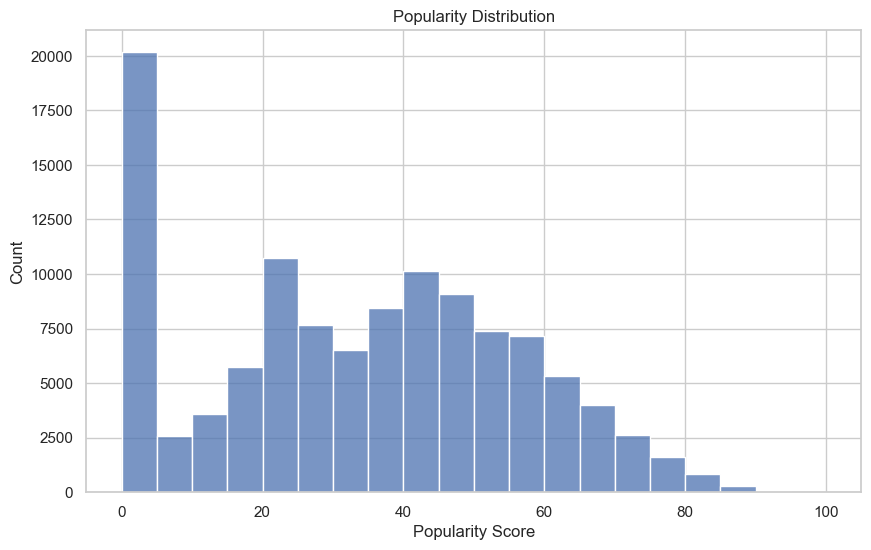

In [185]:
plt.figure(figsize=(10, 6))
sns.histplot(df['popularity'], bins=20, kde=False)
plt.title('Popularity Distribution')
plt.xlabel('Popularity Score')
plt.ylabel('Count')
plt.show()

#### Virality Rate by Genre

In [186]:
genre_virality = (
    df.groupby('track_genre')['viral']
    .mean()
    .sort_values(ascending=False)
)

In [187]:
top_genres = (
    df['track_genre']
    .value_counts()
    .head(20)
    .index
)

df_top = df[df['track_genre'].isin(top_genres)]

genre_virality = (
    df_top.groupby('track_genre')['viral']
    .mean()
    .sort_values(ascending=False)
    
)

Run this cell if you want only the Top 20 Genres by Virality Rate

/var/folders/60/_h9xnrx50j5c1tm68xggnhm00000gn/T/ipykernel_855/4083276584.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


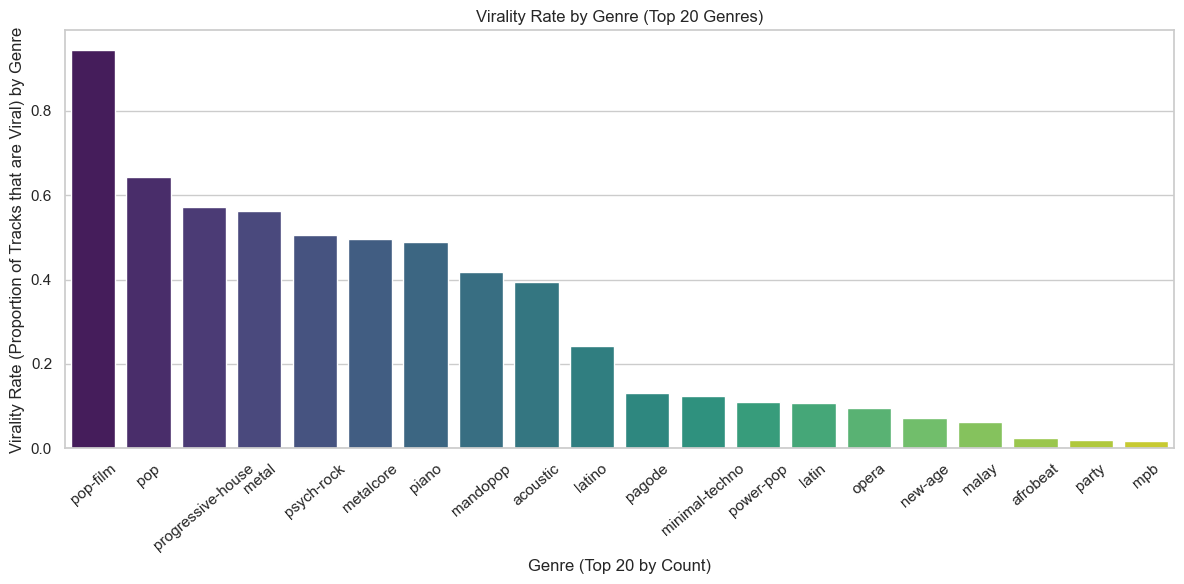

In [188]:
plt.figure(figsize=(12, 6))
sns.barplot(
    x=genre_virality.index,
    y=genre_virality.values,
    palette='viridis'
)

plt.xticks(rotation=40)
plt.title('Virality Rate by Genre (Top 20 Genres)')
plt.xlabel('Genre (Top 20 by Count)')
plt.ylabel('Virality Rate (Proportion of Tracks that are Viral) by Genre')
plt.tight_layout()
plt.show()

#### Popularity Score Distribution Split by Genre

In [189]:
# top_genres = (
#     df['track_genre']
#     .value_counts()
#     .head(10)
#     .index
# )

# df_top = df[df['track_genre'].isin(top_genres)]

# # Sort genres by median popularity for nicer ordering
# genre_order = (
#     df_top.groupby('track_genre')['popularity']
#     .median()
#     .sort_values(ascending=False)
#     .index
# )

# plt.figure(figsize=(10, 8))

# # Create stacked KDEs (ridge-style)
# for i, genre in enumerate(genre_order):
#     subset = df_top[df_top['track_genre'] == genre]
#     sns.kdeplot(
#         data=subset,
#         x='popularity',
#         fill=True,
#         alpha=0.6,
#         linewidth=1,
#         label=genre,
#         clip=(0, 100),
#         bw_adjust=1.0,
#     )

#     # Shift each curve vertically by 1
#     plt.text(
#         x=102,
#         y=subset['popularity'].median(),
#         s=genre,
#         va='center',
#     )

# plt.xlabel('Popularity Score')
# plt.ylabel('Density')
# plt.title('Popularity Distribution by Genre (Top 10 Genres)')
# plt.xlim(0, 100)
# plt.legend().remove()
# plt.tight_layout()
# plt.show()

#### Distribution of Key Audio Features

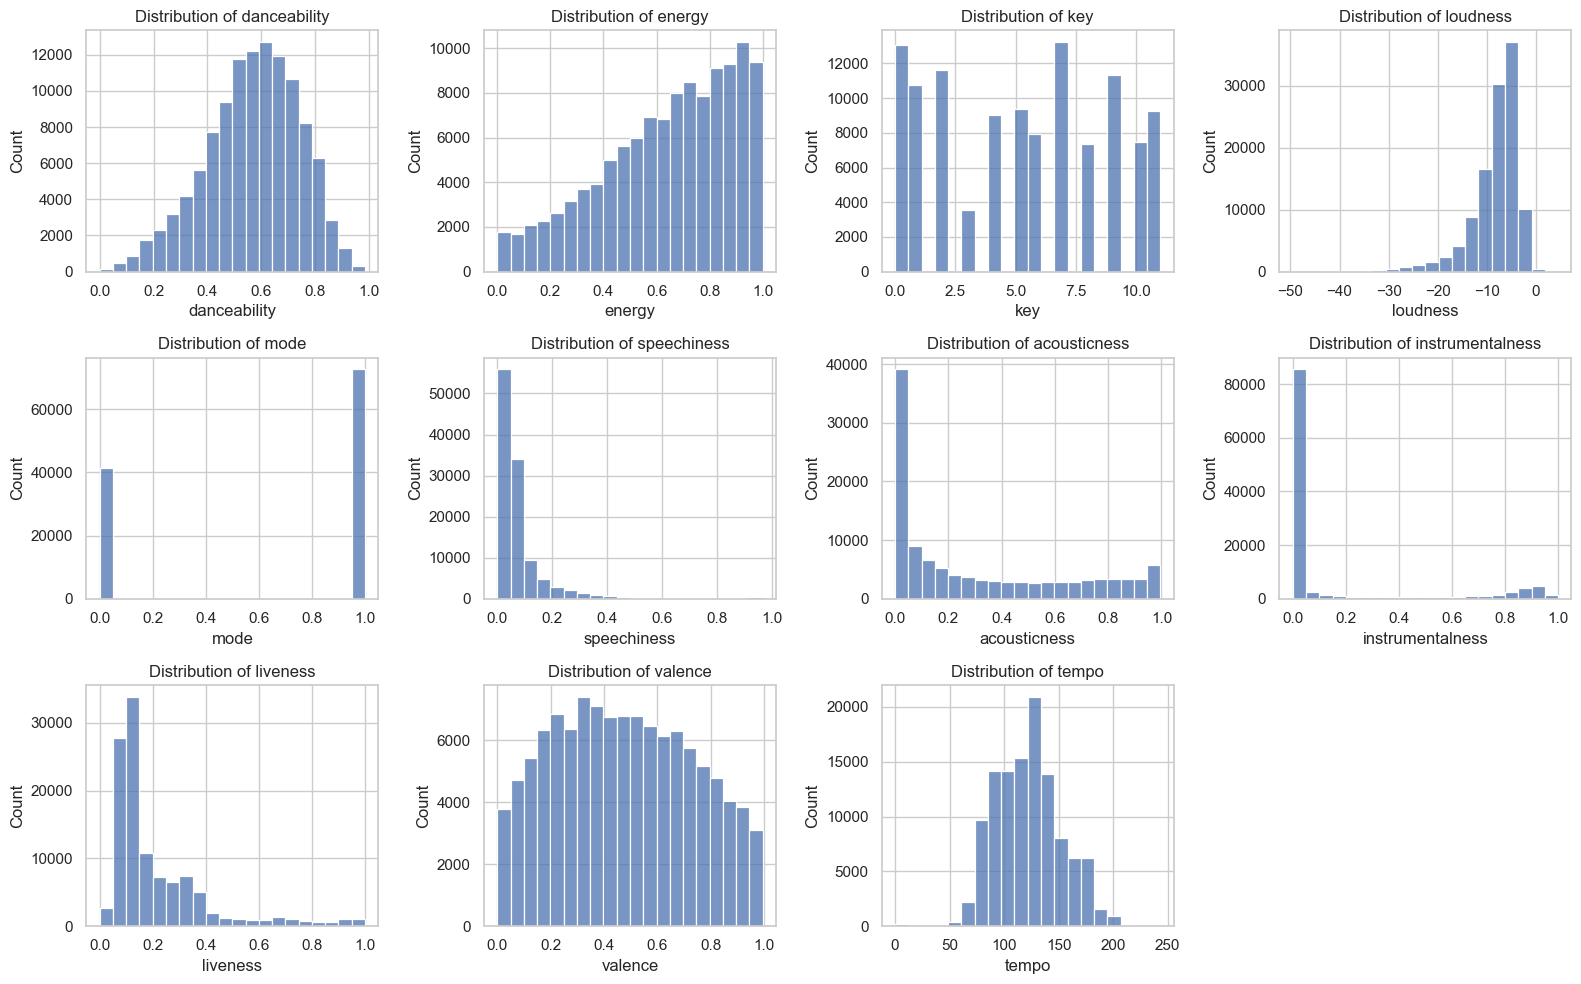

In [190]:
audio_features = ['danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

# Create subplots for each audio feature
n_rows, m_cols = 3, 4
fig, axes = plt.subplots(n_rows, m_cols, figsize=(16, 10))
axes = axes.flatten()

# Plot each audio feature
for i, feature in enumerate(audio_features):
    ax = axes[i]
    sns.histplot(df[feature], bins=20, kde=False, ax=ax)
    ax.set_title(f'Distribution of {feature}')
    ax.set_xlabel(feature)
    ax.set_ylabel('Count')

# Hide any unused subplots (if features < n_rows * m_cols)
for j in range(len(audio_features), n_rows * m_cols):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()




**INSERT ANY INFORMATION**

#### 3.3 Correlation Analysis

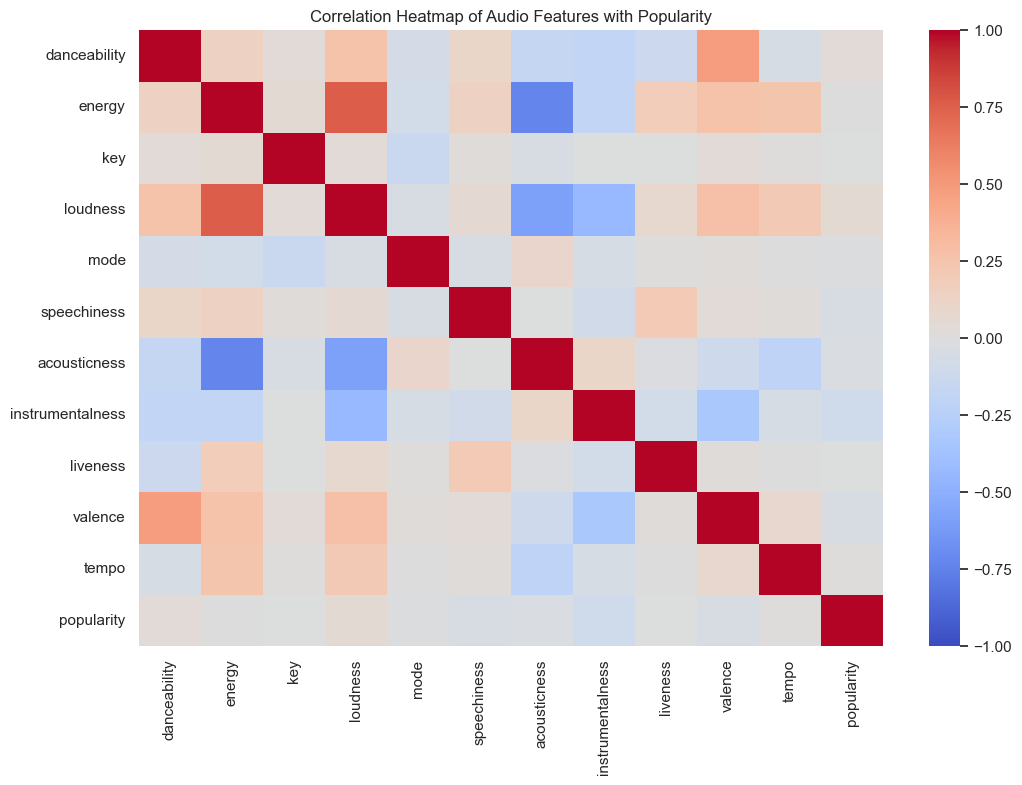

In [191]:
corr_matrix = df[audio_features + ['popularity']].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Correlation Heatmap of Audio Features with Popularity')
plt.show()


**ANNOTATE**

1. energy <-> loudness
2. danceability <-> valence
3. acousticnes <-> energy
4. etc. 

#### Top 20 Most Viral Artists

In [192]:
# Compute artist-level virality rate with minimum track count
artist_stats = (
    df.groupby('artists')
    .agg(
        n_tracks=('track_id', 'count'),
        virality_rate=('viral', 'mean')
    )
)

In [193]:
# Filter to artists with at least 5 tracks
artist_stats = artist_stats[artist_stats['n_tracks'] >= 5]

In [194]:
# Top 20 by virality rate
top20_artists = (
    artist_stats
    .sort_values("virality_rate", ascending=False)
    .head(20)
    .reset_index()
)

/var/folders/60/_h9xnrx50j5c1tm68xggnhm00000gn/T/ipykernel_855/643006696.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/60/_h9xnrx50j5c1tm68xggnhm00000gn/T/ipykernel_855/643006696.py:11: UserWarning: Glyph 39640 (\N{CJK UNIFIED IDEOGRAPH-9AD8}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/60/_h9xnrx50j5c1tm68xggnhm00000gn/T/ipykernel_855/643006696.py:11: UserWarning: Glyph 29246 (\N{CJK UNIFIED IDEOGRAPH-723E}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/60/_h9xnrx50j5c1tm68xggnhm00000gn/T/ipykernel_855/643006696.py:11: UserWarning: Glyph 23459 (\N{CJK UNIFIED IDEOGRAPH-5BA3}) missing from font(s) Arial.
  plt.tight_layout()
/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 39640 (\N{CJK UNIFIED IDEOGR

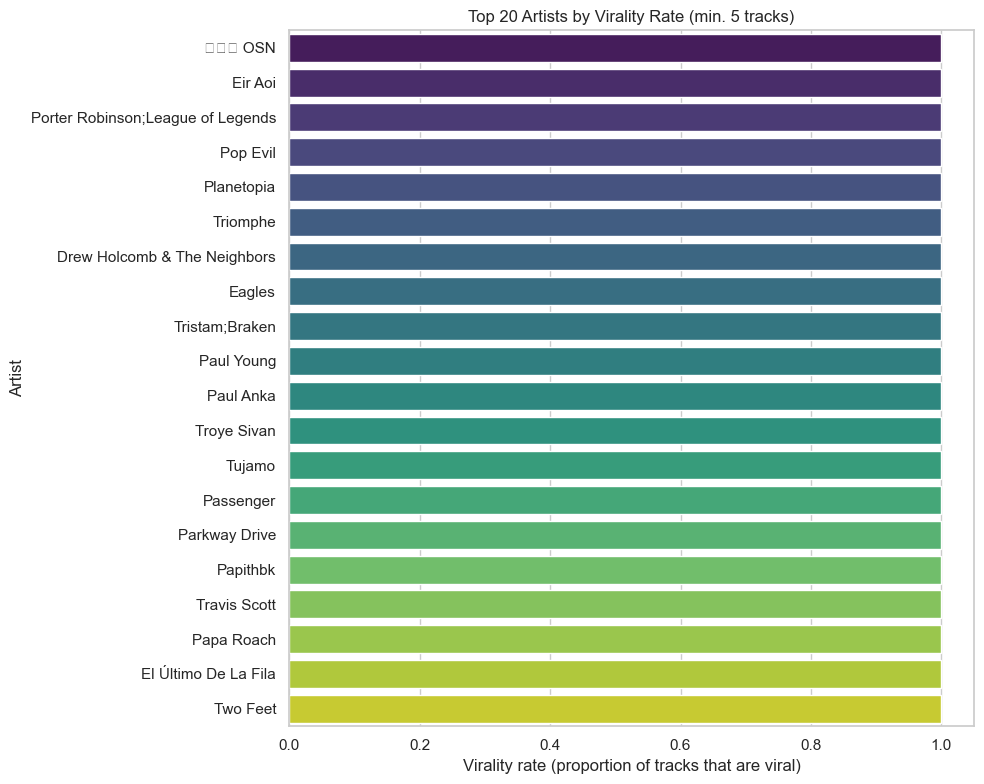

In [195]:
plt.figure(figsize=(10, 8))
sns.barplot(
    data=top20_artists,
    y="artists",
    x="virality_rate",
    palette="viridis"
)
plt.xlabel("Virality rate (proportion of tracks that are viral)")
plt.ylabel("Artist")
plt.title("Top 20 Artists by Virality Rate (min. 5 tracks)")
plt.tight_layout()
plt.show()

#### 3.4 Scatter Plots

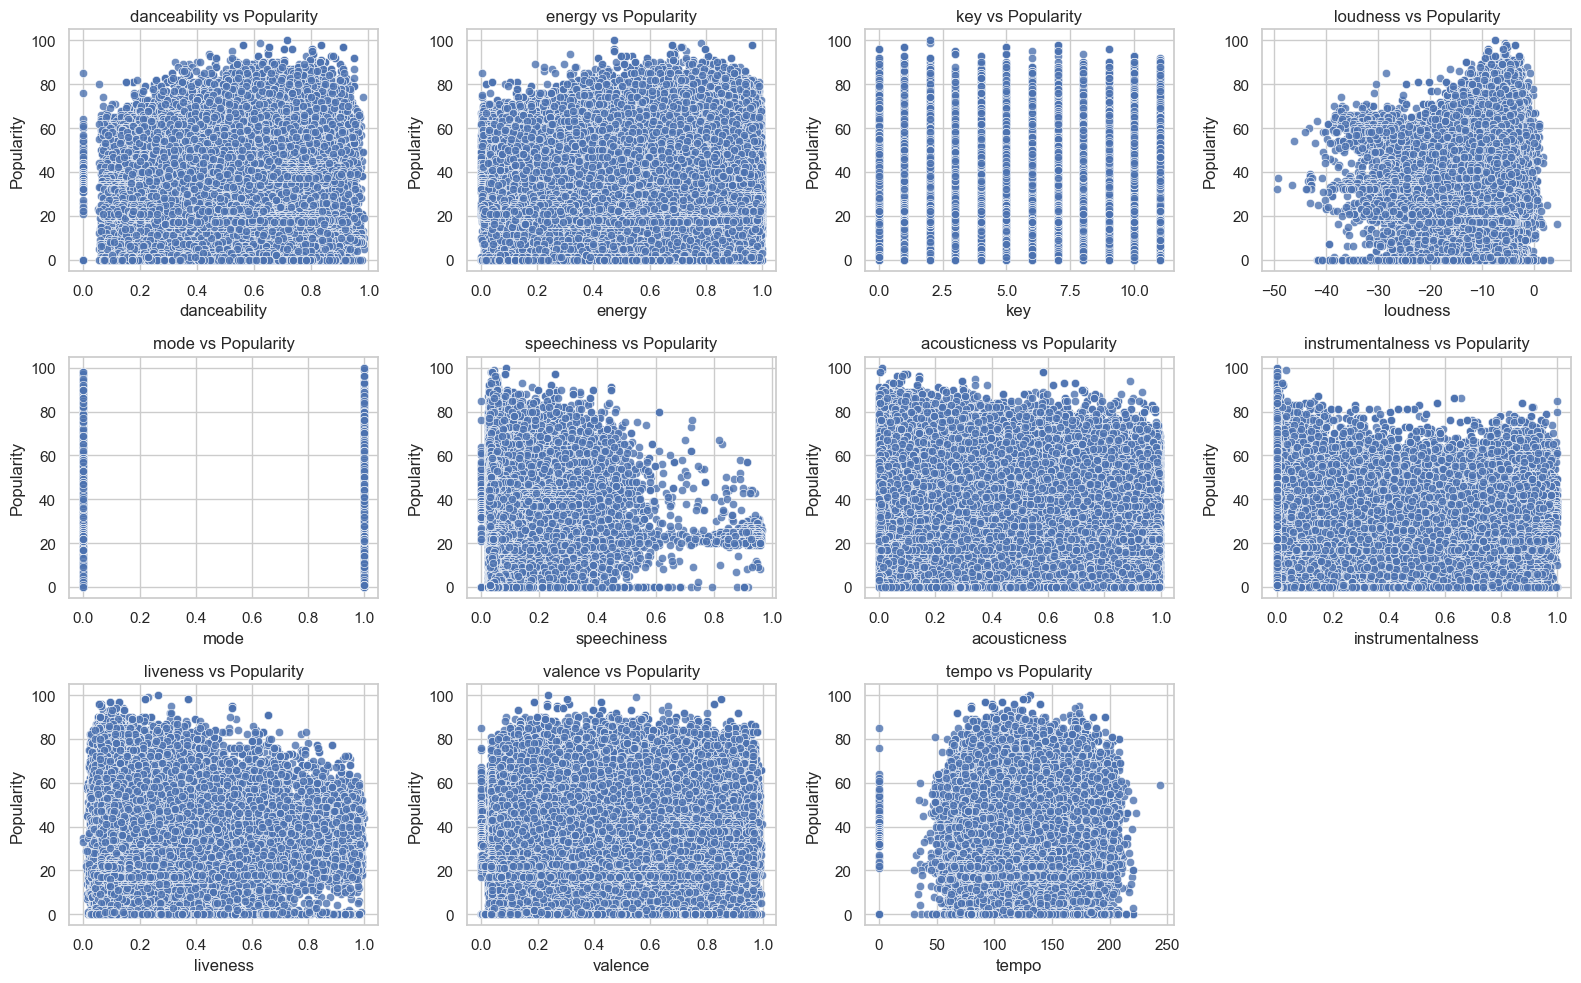

In [196]:
# For each audio feature, plot against popularity
fig, axes = plt.subplots(n_rows, m_cols, figsize=(16, 10))
axes = axes.flatten()

for i, feature in enumerate(audio_features):
    ax = axes[i]
    sns.scatterplot(x=feature, y='popularity', data=df, ax=ax, alpha=0.8)
    ax.set_title(f'{feature} vs Popularity')
    ax.set_xlabel(feature)
    ax.set_ylabel('Popularity')

# Hide any unused subplots (if features < n_rows * m_cols)
for j in range(len(audio_features), n_rows * m_cols):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**ANNOTATE**

#### 3.5 Boxplots

Viral vs. Non-Viral Comparisons

In [197]:
import seaborn as sns
import matplotlib.pyplot as plt

def boxplot_with_green_red(df, feature, target_col="viral", labels=("Non‑viral", "Viral")):
    """
    Colors the group with higher median feature value as green, the other as red.
    Assumes target_col is binary 0/1.
    """
    medians = df.groupby(target_col)[feature].median()
    # Decide which label (0 or 1) is 'better' (higher median)
    better = medians.idxmax()      # 0 or 1
    worse  = 1 - better

    palette = {
        "0": "green" if better == 0 else "red",
        "1": "green" if better == 1 else "red",
    }

    plt.figure(figsize=(6, 4))
    ax = sns.boxplot(data=df, x=target_col, y=feature, palette=palette)
    ax.set_xticklabels(labels)
    ax.set_title(f"{feature} by Virality\n(green = higher median)")
    plt.show()

/var/folders/60/_h9xnrx50j5c1tm68xggnhm00000gn/T/ipykernel_855/569189.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/60/_h9xnrx50j5c1tm68xggnhm00000gn/T/ipykernel_855/569189.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Non‑viral", "Viral"])
/var/folders/60/_h9xnrx50j5c1tm68xggnhm00000gn/T/ipykernel_855/569189.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/60/_h9xnrx50j5c1tm68xggnhm00000gn/T/ipykernel_855/569189.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLoca

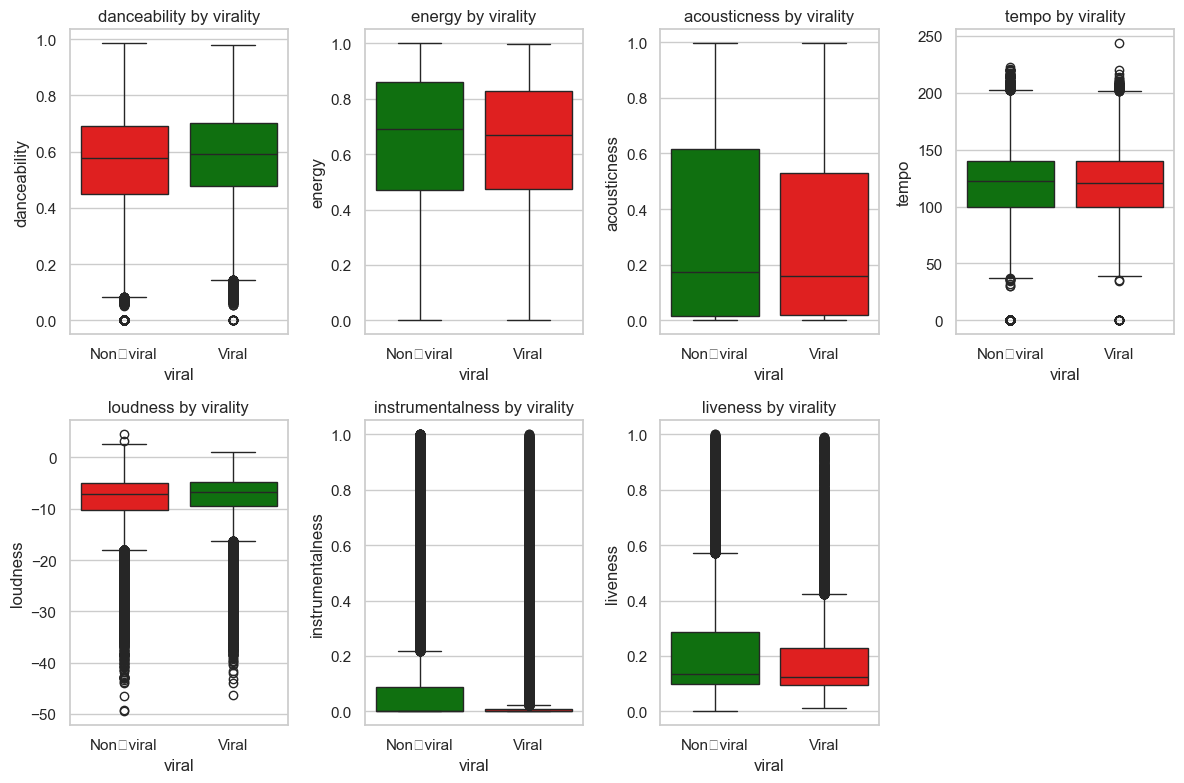

In [198]:
import matplotlib.pyplot as plt
import seaborn as sns

features = ["danceability", "energy", "acousticness", "tempo", "loudness", "instrumentalness", "liveness"]
n_rows, n_cols = 2, 4

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(features):
    ax = axes[i]

    # Compute which class has higher median for this feature
    medians = df.groupby("viral")[feature].median()
    better = medians.idxmax()        # 0 or 1

    # Palette: better group green, other red (string keys to be safe)
    better_key = str(better)
    palette = {
        "0": "green" if better_key == "0" else "red",
        "1": "green" if better_key == "1" else "red",
    }

    sns.boxplot(
        data=df,
        x="viral",
        y=feature,
        palette=palette,
        ax=ax
    )
    ax.set_title(f"{feature} by virality")
    ax.set_xticklabels(["Non‑viral", "Viral"])

# Hide any unused axes if features < n_rows * n_cols
for j in range(len(features), n_rows * n_cols):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### 4. Feature Engineering

#### 4.1 Feature Selection

Dataset will be save to: `data/processed` for necessary usage in modeling

In [199]:
df = df.drop(columns=["Unnamed: 0", "track_id", "artists", "album_name", "track_name", "popularity"], axis=1)

print("Attributes kept:")
print(df.columns)


Attributes kept:
Index(['duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature', 'track_genre', 'viral'],
      dtype='object')


In [200]:
# Correlation with viral
popularity_correlation = (
    df.select_dtypes(include=[np.number])
      .corr()['viral']
      .drop('viral')
)

# Convert to list
pop_corr_list = popularity_correlation.values.tolist()
# Absolute value
pop_corr_list_abs = [abs(ele) for ele in pop_corr_list]

In [201]:
def average(l) -> float:
    """
    Calculate the average of a list

    Args:
        l (list): List of numbers

    Returns:
        float: Average of the list
    """
    return sum(l) / len(l)

# Average correlation
pop_corr_list_abs_avg = average(pop_corr_list_abs)

In [202]:
# Convert to dataframe
pop_corr_df = popularity_correlation.to_frame()

# Add absolute value of correlation
pop_corr_df['viral_abs'] = abs(pop_corr_df['viral'])

# Select features with correlation greater than average
pop_corr_abv = pop_corr_df[(pop_corr_df['viral_abs'] > pop_corr_list_abs_avg)]

# Sort by absolute value of correlation
pop_corr_abv = pop_corr_abv.sort_values(by=['viral_abs'], ascending=False)

pop_corr_abv.head()

,viral,viral_abs
liveness,-0.086908,0.086908
instrumentalness,-0.081801,0.081801
danceability,0.052040,0.052040
speechiness,-0.049383,0.049383
duration_ms,-0.040975,0.040975


**MIGHT NEED TO VISUALISE THE ABOVE CODE WITH SOME GRAPH**

#### Point-Biserial Correlation Bar Chart

In [203]:
corr_plot_df = (
    pop_corr_df
    .sort_values('viral_abs', ascending=True)
)

/var/folders/60/_h9xnrx50j5c1tm68xggnhm00000gn/T/ipykernel_855/608247660.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/60/_h9xnrx50j5c1tm68xggnhm00000gn/T/ipykernel_855/608247660.py:5: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sns.barplot(


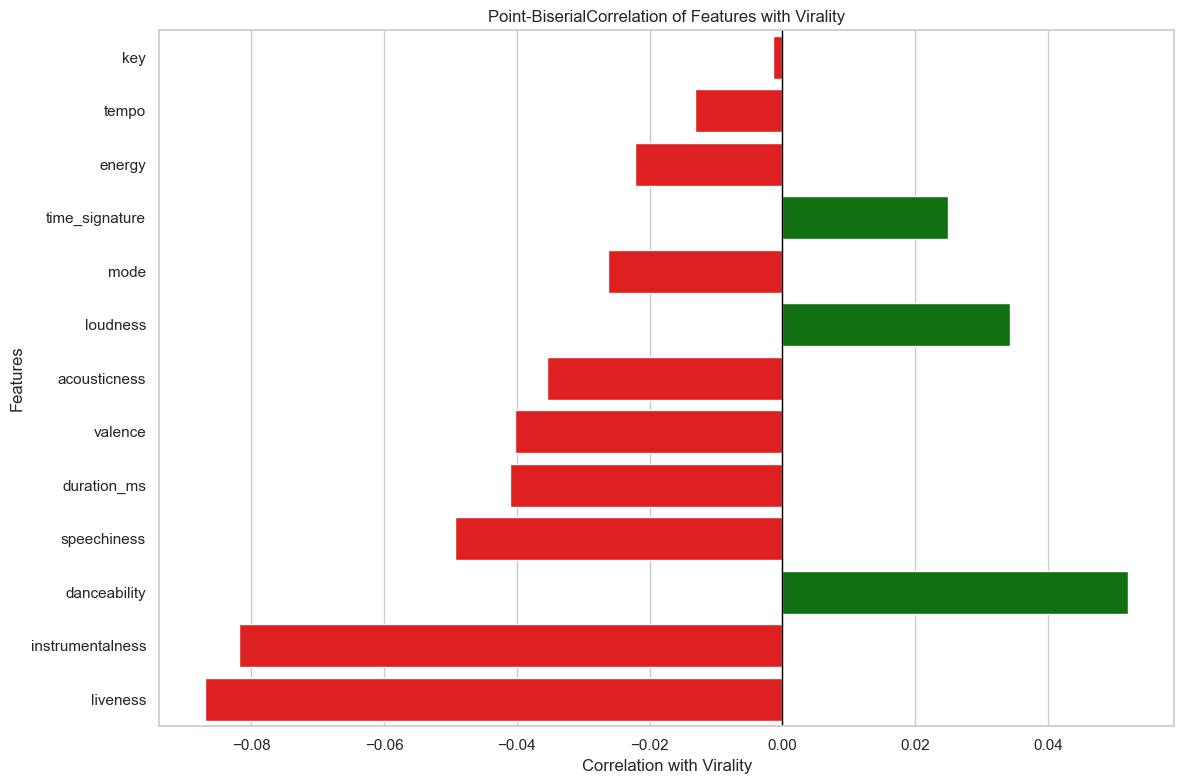

In [204]:
# Color positive vs negative correlations
colors = corr_plot_df['viral'].apply(lambda x: 'green' if x > 0 else 'red')

plt.figure(figsize=(12, 8))
sns.barplot(
    x='viral',
    y=corr_plot_df.index,
    data=corr_plot_df.reset_index(),
    palette=colors.values
)

plt.axvline(0, color='black', linewidth=1)
plt.xlabel('Correlation with Virality')
plt.ylabel('Features')
plt.title('Point-BiserialCorrelation of Features with Virality')
plt.tight_layout()
plt.show()

#### Pairplot of Top 4 Features Coloured by Virality

In [205]:
top4_features = (
    pop_corr_df
    .sort_values('viral_abs', ascending=False)
    .head(4)
    .index
    .tolist()
)

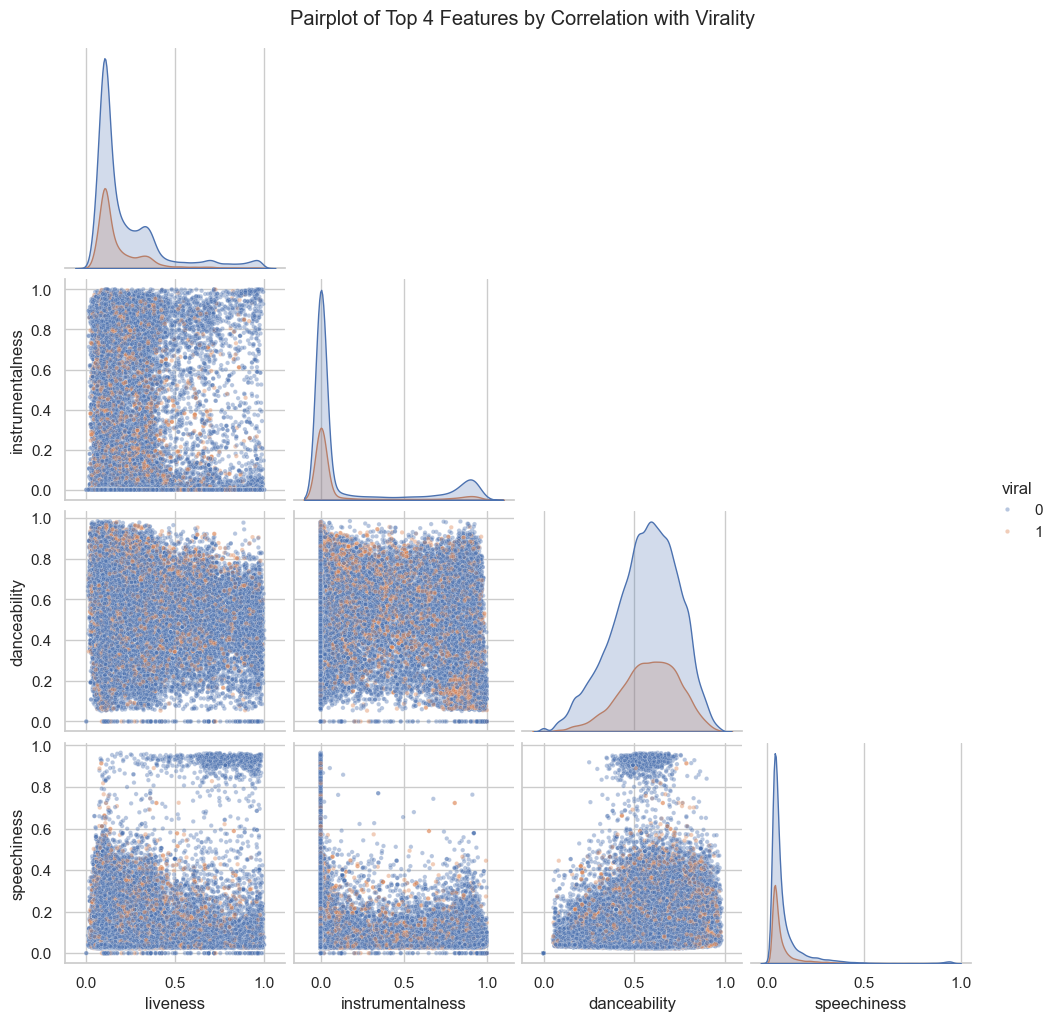

In [206]:
sns.pairplot(
    df[top4_features + ['viral']],
    hue='viral',
    corner=True,
    diag_kind='kde',
    plot_kws={'alpha': 0.4, 's': 10}
)

plt.suptitle('Pairplot of Top 4 Features by Correlation with Virality', y=1.02)
plt.show()

#### Explicit vs Non-Explicit Virality Rate

In [207]:
explicit_virality = (
    df.groupby('explicit')['viral']
    .mean()
    .reset_index()
)

explicit_virality['explicit'] = explicit_virality['explicit'].map({False: 'Non-explicit', True: 'Explicit'})

/var/folders/60/_h9xnrx50j5c1tm68xggnhm00000gn/T/ipykernel_855/1875114606.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


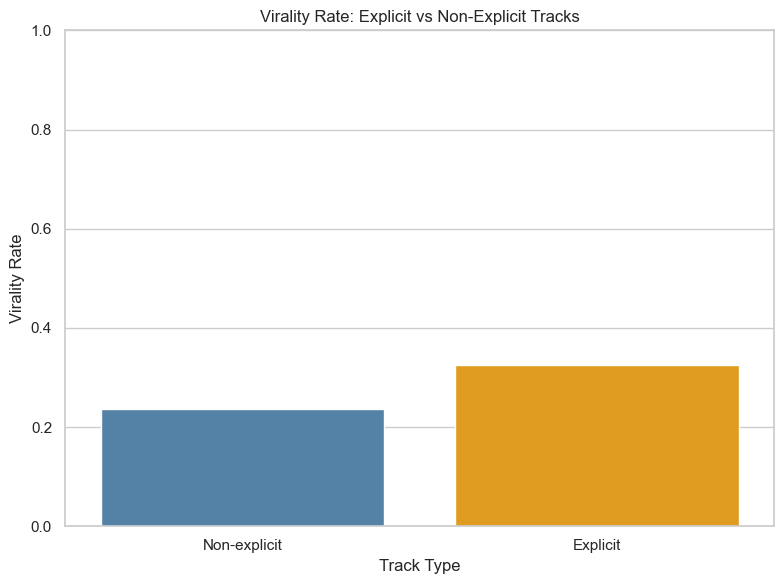

In [208]:
plt.figure(figsize=(8, 6))
sns.barplot(
    data=explicit_virality,
    x='explicit',
    y='viral',
    palette=['steelblue', 'orange']
)

plt.xlabel('Track Type')
plt.ylabel('Virality Rate')
plt.title('Virality Rate: Explicit vs Non-Explicit Tracks')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

#### t-SNE Projection of Audio Features

In [212]:
print(audio_features)

['danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']


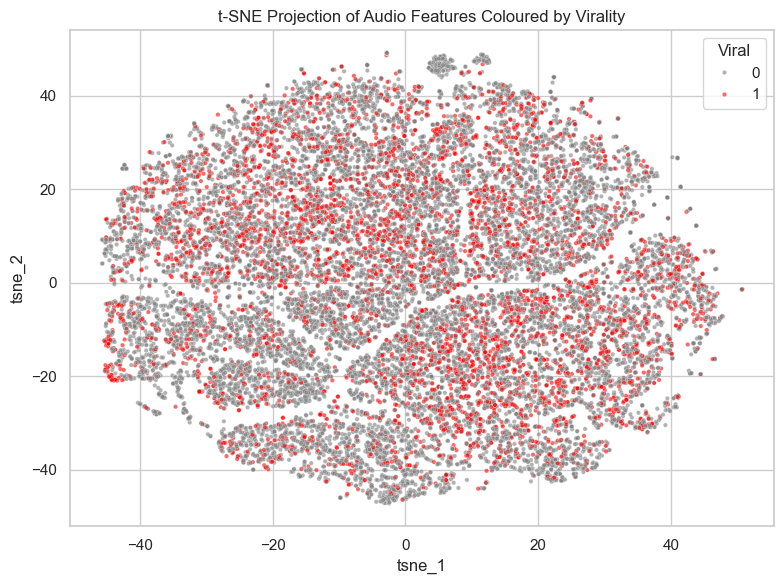

In [213]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

features = audio_features
X = df[features].values
y = df["viral"].values

# Standardise features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Run t-SNE (subsample if needed for speed)
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    random_state=42,
    init="pca",
)
X_embedded = tsne.fit_transform(X_scaled)

tsne_df = pd.DataFrame({
    "tsne_1": X_embedded[:, 0],
    "tsne_2": X_embedded[:, 1],
    "viral": y
})

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=tsne_df.sample(min(len(tsne_df), 20000), random_state=42),  # subsample for clarity
    x="tsne_1",
    y="tsne_2",
    hue="viral",
    palette={0: "grey", 1: "red"},
    alpha=0.6,
    s=10
)
plt.title("t-SNE Projection of Audio Features Coloured by Virality")
plt.legend(title="Viral")
plt.tight_layout()
plt.show()

#### UMAP Projection of Audio Features

In [215]:
import umap

In [216]:
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=30,
    min_dist=0.1,
    random_state=42,
)
X_umap = reducer.fit_transform(X_scaled)

umap_df = pd.DataFrame({
    "umap_1": X_umap[:, 0],
    "umap_2": X_umap[:, 1],
    "viral": y
})

/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


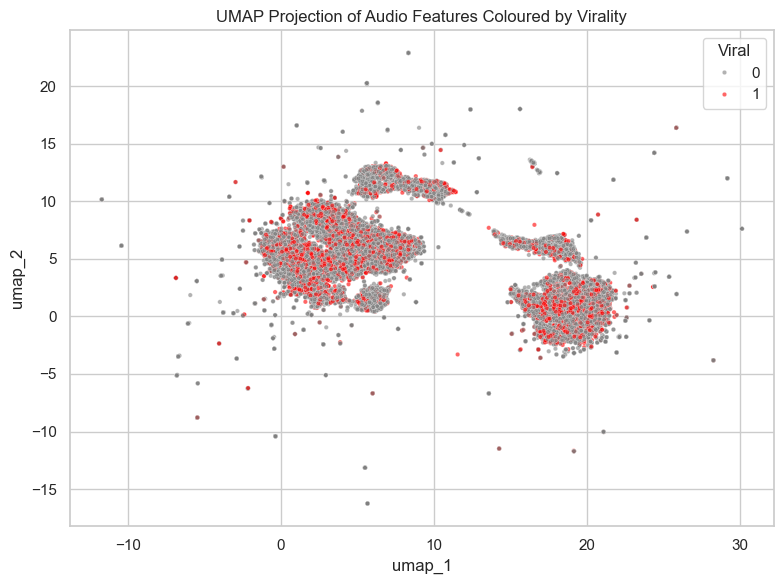

In [217]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=umap_df.sample(min(len(umap_df), 20000), random_state=42),
    x="umap_1",
    y="umap_2",
    hue="viral",
    palette={0: "grey", 1: "red"},
    alpha=0.6,
    s=10
)
plt.title("UMAP Projection of Audio Features Coloured by Virality")
plt.legend(title="Viral")
plt.tight_layout()
plt.show()

#### 4.2 One-Hot Encoding

In [209]:
dummies_var = ['explicit', 'track_genre']

final_df = pd.get_dummies(df, prefix=dummies_var, columns=dummies_var, drop_first=True)

final_df.head()


,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,...,track_genre_spanish,track_genre_study,track_genre_swedish,track_genre_synth-pop,track_genre_tango,track_genre_techno,track_genre_trance,track_genre_trip-hop,track_genre_turkish,track_genre_world-music
0,230666,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,...,False,False,False,False,False,False,False,False,False,False
1,149610,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,...,False,False,False,False,False,False,False,False,False,False
2,210826,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,...,False,False,False,False,False,False,False,False,False,False
3,201933,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,...,False,False,False,False,False,False,False,False,False,False
4,198853,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,...,False,False,False,False,False,False,False,False,False,False


In [210]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 113999 entries, 0 to 113999
Columns: 128 entries, duration_ms to track_genre_world-music
dtypes: bool(114), float64(9), int64(5)
memory usage: 25.4 MB


In [ ]:
OUTPUT_PATH = "../data/processed/spotify_tracks_cleaned.csv"

os.makedirs("../data/processed", exist_ok=True)
final_df.to_csv(OUTPUT_PATH, index=False)
print(f"Cleaned dataset saved to: {OUTPUT_PATH}")